# Ejemplos de codigo - Adult

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd


In [3]:
import numpy as np


In [4]:
import matplotlib.pyplot as plt


In [5]:
import seaborn as sns


In [6]:
from scipy.stats import shapiro


In [7]:
sns.set_theme(style="whitegrid")


In [8]:
# Cargar datos
data = pd.read_csv("adult.csv")


In [9]:
# 1) Informacion basica
data.shape


(45222, 12)

In [10]:
# 2) Revision inicial
data.head()


,age,workclass,education_num,marital_status,occupation,relationship,race,gender,hours_per_week,native_country,capital,income_status
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,2174,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,0,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,0,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Other,Male,40,United-States,0,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Other,Female,40,Other,0,<=50K


In [11]:
# 3) Variables de trabajo
vars_categoricas = ["workclass", "income_status", "gender"]
vars_numericas = ["age", "education_num", "hours_per_week", "capital"]


In [12]:
# 4) Descripcion de variables y observaciones
data[vars_numericas].describe()


,age,education_num,hours_per_week,capital
count,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,40.938017,1012.834925
std,13.217870,2.552881,12.007508,7530.315380
min,17.000000,1.000000,1.000000,-4356.000000
25%,28.000000,9.000000,40.000000,0.000000
50%,37.000000,10.000000,40.000000,0.000000
75%,47.000000,13.000000,45.000000,0.000000
max,90.000000,16.000000,99.000000,99999.000000


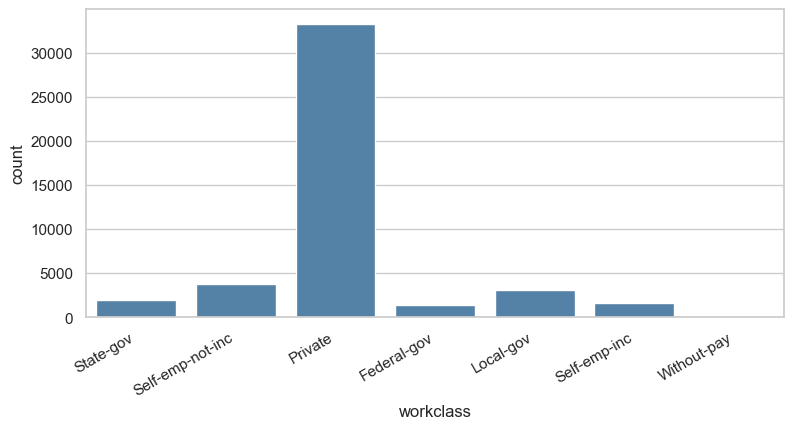

In [13]:
# 5) Grafico de barras (categorica)
plt.figure(figsize=(9, 4))
sns.countplot(data=data, x="workclass", color="steelblue")
plt.xticks(rotation=30, ha="right")
plt.show()


In [14]:
# 6) Tabla de medidas numericas
data[vars_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
age,45222.0,38.547941,13.217870,17.0,28.0,37.0,47.0,90.0
education_num,45222.0,10.118460,2.552881,1.0,9.0,10.0,13.0,16.0
hours_per_week,45222.0,40.938017,12.007508,1.0,40.0,40.0,45.0,99.0
capital,45222.0,1012.834925,7530.315380,-4356.0,0.0,0.0,0.0,99999.0


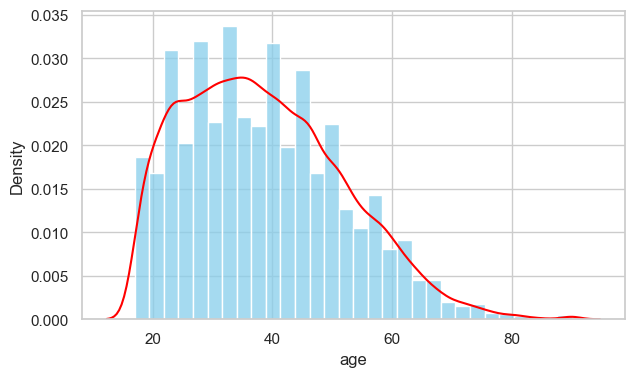

In [15]:
# 7) Histograma + densidad
plt.figure(figsize=(7, 4))
sns.histplot(data=data, x="age", bins=30, stat="density", color="skyblue")
sns.kdeplot(data=data, x="age", color="red")
plt.show()


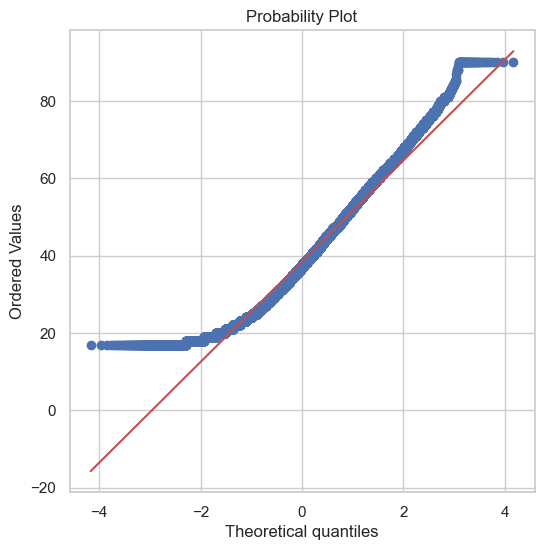

In [16]:
# 8a) Q-Q plot
import scipy.stats as stats
plt.figure(figsize=(6, 6))
stats.probplot(data["age"].dropna(), dist="norm", plot=plt)
plt.show()


In [17]:
# 8b) Prueba Shapiro (muestra para mantener simple)
np.random.seed(123)
age_sample = data["age"].dropna().sample(n=min(5000, data["age"].dropna().shape[0]), random_state=123)
shapiro(age_sample)


ShapiroResult(statistic=np.float64(0.9690239071114602), pvalue=np.float64(1.5615696018796184e-31))

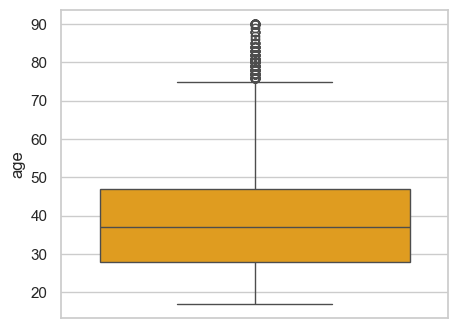

In [19]:
# 9) Boxplot de atipicos
plt.figure(figsize=(5, 4))
sns.boxplot(y=data["age"], color="orange")
plt.show()


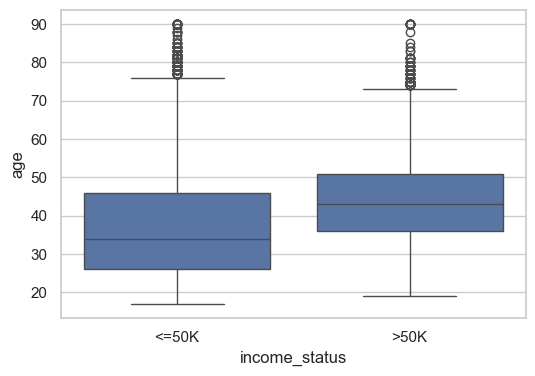

In [20]:
# 10) Numerica vs categorica (boxplot)
plt.figure(figsize=(6, 4))
sns.boxplot(data=data, x="income_status", y="age")
plt.show()


In [ ]:
# 11) Faltantes por columna (tabla)
# NOTA: Este dataset no tiene faltantes, pero se muestra el codigo para que lo puedan usar en otros casos
data.isna().sum()

age               0
workclass         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
gender            0
hours_per_week    0
native_country    0
capital           0
income_status     0
dtype: int64

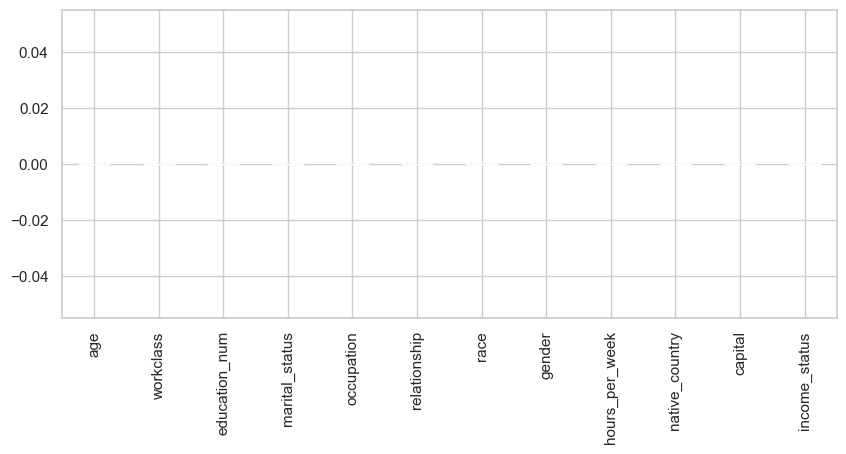

In [ ]:
# 11) Faltantes por columna (grafico)
# NOTA: Este dataset no tiene faltantes, pero se muestra el codigo para que lo puedan usar en otros casos

faltantes = data.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
faltantes.plot(kind="bar", color="purple")
plt.show()


In [25]:
# 12) Matriz de correlacion
cor_mat = data[vars_numericas].corr(numeric_only=True)
cor_mat


,age,education_num,hours_per_week,capital
age,1.000000,0.037623,0.101992,0.076239
education_num,0.037623,1.000000,0.146206,0.122110
hours_per_week,0.101992,0.146206,1.000000,0.080700
capital,0.076239,0.122110,0.080700,1.000000


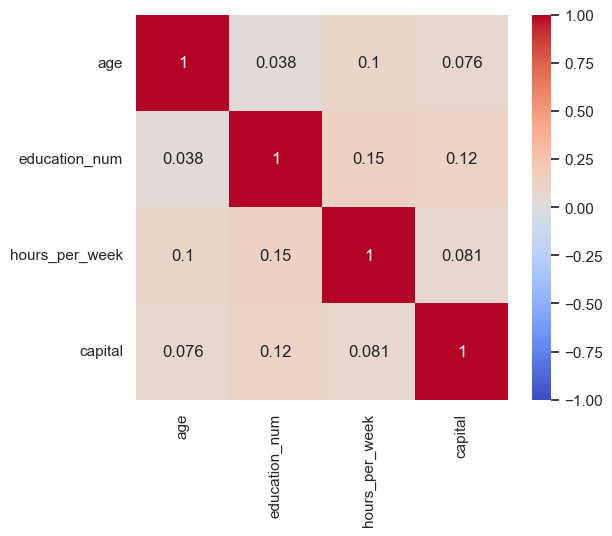

In [26]:
# 12) Heatmap correlacion
plt.figure(figsize=(6, 5))
sns.heatmap(cor_mat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()
